# Import config file which stores all hyperparameter values

In [1]:
import os 
import configparser

In [2]:
config_path = "configs/Training_config2.ini"
config_read = configparser.ConfigParser()
config_read.read(config_path)

['configs/Training_config2.ini']

In [3]:
for sect in config_read.sections():
    print('Title:', sect)
    for k,v in config_read.items(sect):
        print(' {} = {}'.format(k,v))
    print()

Title: TrainingInfo
 traindataset = ['jaadall_with_c_g/train/']
 loss = BCE
 save_model_folder_acc = training_results/best_val_acc/
 save_model_folder_f1 = training_results/best_val_f1/
 batch_size = 500
 stratifiedkfold_random_state = 1
 graph_seed = 2676
 1dcnn_seed = 2726



In [4]:
import json
train_folder = json.loads(config_read.get("TrainingInfo", "traindataset").replace("'",'"'))
loss_name = config_read.get("TrainingInfo", "loss")
save_model_folder_acc = config_read.get("TrainingInfo", "save_model_folder_acc")
save_model_folder_f1 = config_read.get("TrainingInfo", "save_model_folder_f1")
batch_size = int(config_read.get("TrainingInfo", "batch_size"))
ran_2 = int(config_read.get("TrainingInfo", "stratifiedkfold_random_state"))

In [5]:
train_folder

['jaadall_with_c_g/train/']

# Load training data 

In [6]:
import os

In [7]:
import numpy as np


In [8]:
root = 'preprocessed_data/'+train_folder[0]
x_t_train, y_t_train = np.load(root + 'x_t.npy'), np.load(root + 'y.npy')


In [9]:
print(x_t_train.shape, y_t_train.shape)

(162254, 16, 5) (162254, 1)


In [10]:
def count_imbalance(y_t):
    count_pos, count_neg = 0, 0
    for label in y_t:
        if label == [1.0]:
            count_pos+=1
        else:
            count_neg+=1
    if count_pos>count_neg:
        print('Negative class is minority class')
    else:
        print('Positive class is minority class')
        
    print('Imbalance ratio: {0}:{1}'.format(str(round(count_pos/len(y_t),2)), str(round(count_neg/len(y_t),2))))
    print('Number of sample deficit: {0}'.format(str(abs(count_pos-count_neg))))
    return count_pos/(count_pos+count_neg)

In [11]:
alpha = count_imbalance(y_t_train)

Positive class is minority class
Imbalance ratio: 0.09:0.91
Number of sample deficit: 133776


In [12]:
pos_indices = np.squeeze(y_t_train==1)
neg_indices = np.squeeze(y_t_train==0)

# split pos/neg
x_t_pos_train = x_t_train[pos_indices]
y_t_pos_train = y_t_train[pos_indices]

x_t_neg_train = x_t_train[neg_indices]
y_t_neg_train = y_t_train[neg_indices]

x_shuffle_neg_indices = [i for i in range(len(y_t_neg_train))]
np.random.seed(10)
np.random.shuffle(x_shuffle_neg_indices)

In [13]:
import random
random.seed(38)
shuffle_indices = random.sample(x_shuffle_neg_indices, len(y_t_pos_train)*5)

In [14]:
pos_num = len(y_t_pos_train)
folds = 5
for i in range(folds):
    neg_fold_indices = [i*pos_num, i*pos_num+pos_num]

In [15]:
neg_fold_indices

[56956, 71195]

In [17]:
len(y_t_neg_train)

148015

# Prepare a training function

In [21]:
import os
import torch 
import numpy as np
import utils.data_loader as Dataset
from torch.utils.data import DataLoader
import models.onedcnn_model_16frames as Onedcnn
from sklearn.model_selection import StratifiedKFold

Fold 1:
Dataloader seed: 2726
[INFO]: Epoch 2 of 200


/data/home/acw607/stacking/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Training loss: 0.662, training acc: 51.000
Validation loss: 0.661, validation acc: 50.000
--------------------------------------------------

Best validation acc: 50.0

Saving best model for epoch: 2


Best validation f1: 0.33

Saving best model for epoch: 2

[INFO]: Epoch 3 of 200


/data/home/acw607/stacking/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Training loss: 0.661, training acc: 51.000
Validation loss: 0.661, validation acc: 50.000
--------------------------------------------------
[INFO]: Epoch 4 of 200
Training loss: 0.660, training acc: 51.000
Validation loss: 0.660, validation acc: 51.000
--------------------------------------------------

Best validation acc: 51.0

Saving best model for epoch: 4


Best validation f1: 0.36

Saving best model for epoch: 4

[INFO]: Epoch 5 of 200
Training loss: 0.659, training acc: 51.000
Validation loss: 0.659, validation acc: 52.000
--------------------------------------------------

Best validation acc: 52.0

Saving best model for epoch: 5


Best validation f1: 0.41

Saving best model for epoch: 5

[INFO]: Epoch 6 of 200
Training loss: 0.657, training acc: 52.000
Validation loss: 0.657, validation acc: 53.000
--------------------------------------------------

Best validation acc: 53.0

Saving best model for epoch: 6


Best validation f1: 0.51

Saving best model for epoch: 6

[INFO]: Ep

...

Training loss: 0.662, training acc: 50.000
Validation loss: 0.661, validation acc: 50.000
--------------------------------------------------

Best validation acc: 50.0

Saving best model for epoch: 2


Best validation f1: 0.33

Saving best model for epoch: 2

[INFO]: Epoch 3 of 200


/data/home/acw607/stacking/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Training loss: 0.661, training acc: 50.000
Validation loss: 0.661, validation acc: 50.000
--------------------------------------------------
[INFO]: Epoch 4 of 200


/data/home/acw607/stacking/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Training loss: 0.659, training acc: 50.000
Validation loss: 0.657, validation acc: 50.000
--------------------------------------------------
[INFO]: Epoch 5 of 200
Training loss: 0.656, training acc: 51.000
Validation loss: 0.653, validation acc: 55.000
--------------------------------------------------

Best validation acc: 55.00000000000001

Saving best model for epoch: 5


Best validation f1: 0.55

Saving best model for epoch: 5

[INFO]: Epoch 6 of 200
Training loss: 0.649, training acc: 54.000
Validation loss: 0.643, validation acc: 60.000
--------------------------------------------------

Best validation acc: 60.0

Saving best model for epoch: 6


Best validation f1: 0.6

Saving best model for epoch: 6

[INFO]: Epoch 7 of 200
Training loss: 0.641, training acc: 58.000
Validation loss: 0.632, validation acc: 62.000
--------------------------------------------------

Best validation acc: 62.0

Saving best model for epoch: 7


Best validation f1: 0.62

Saving best model for epoch: 7

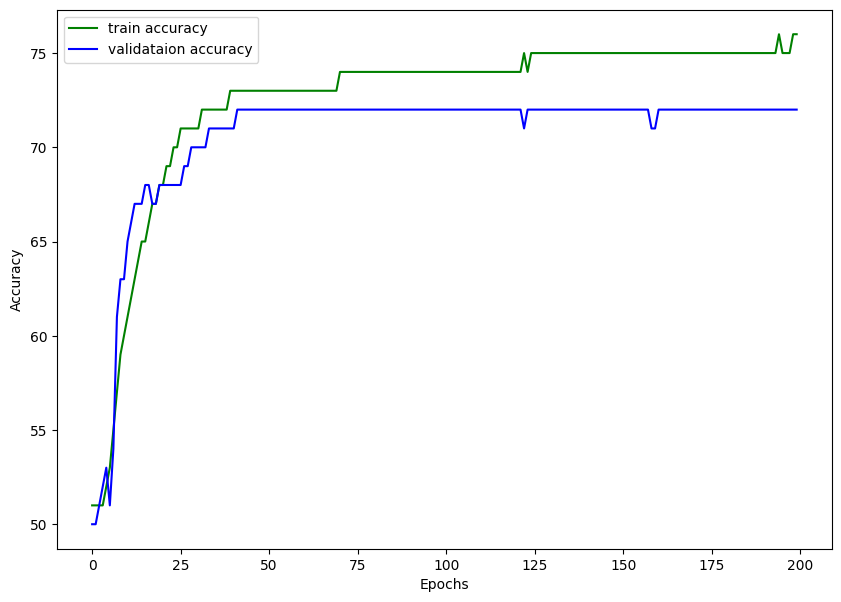

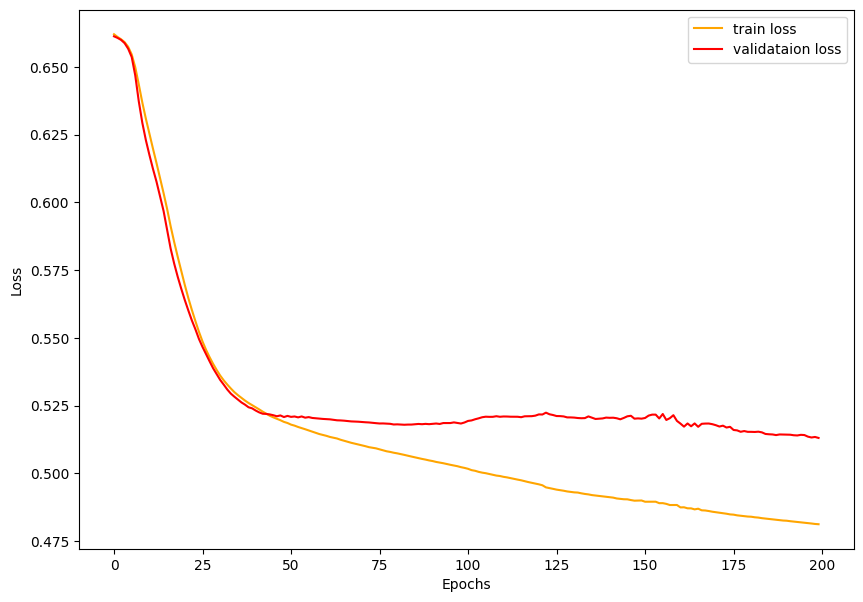

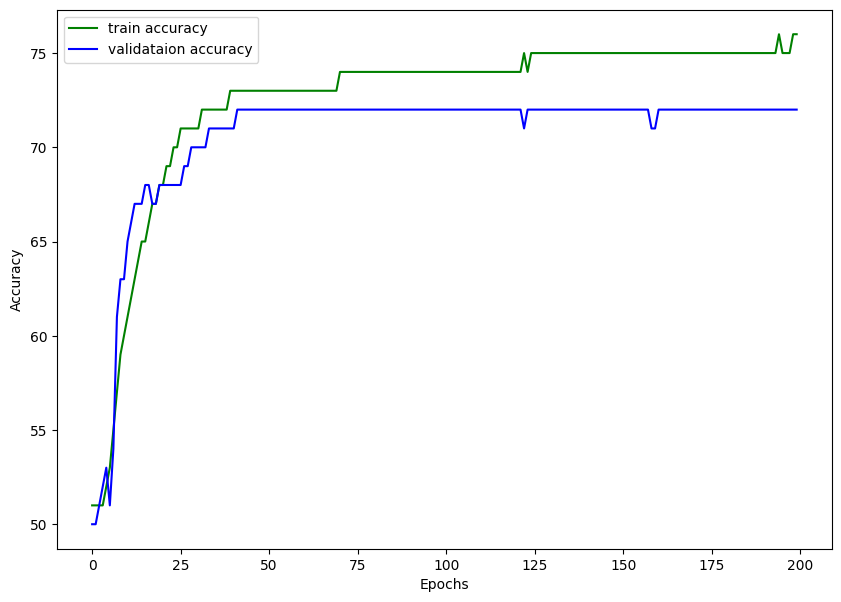

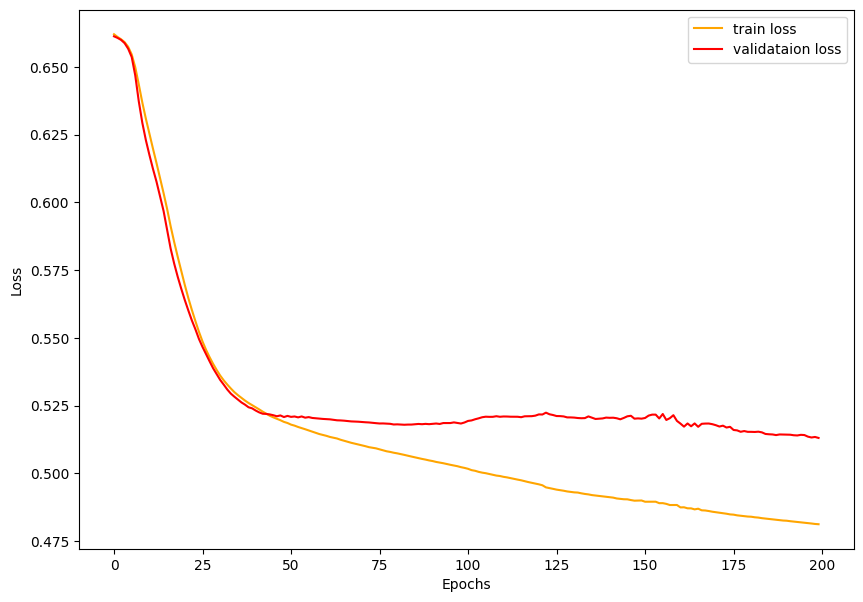

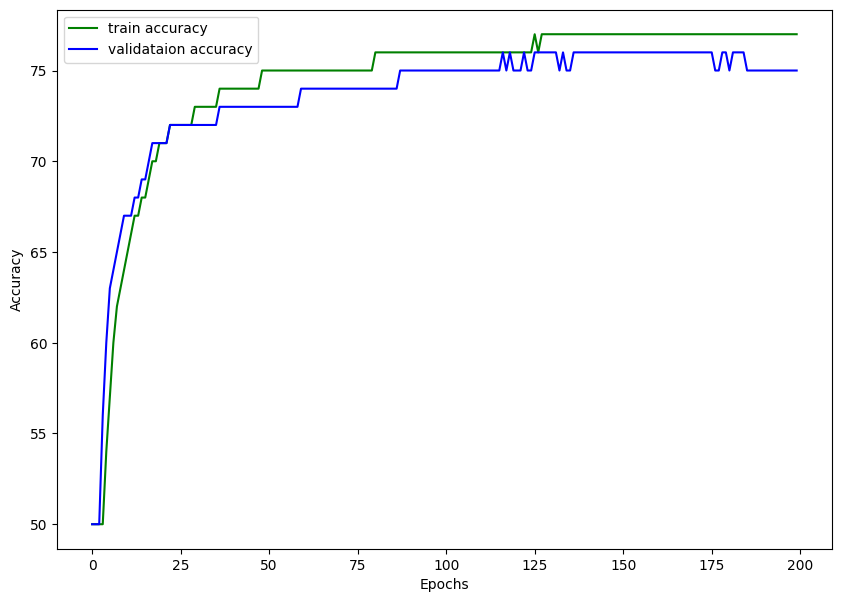

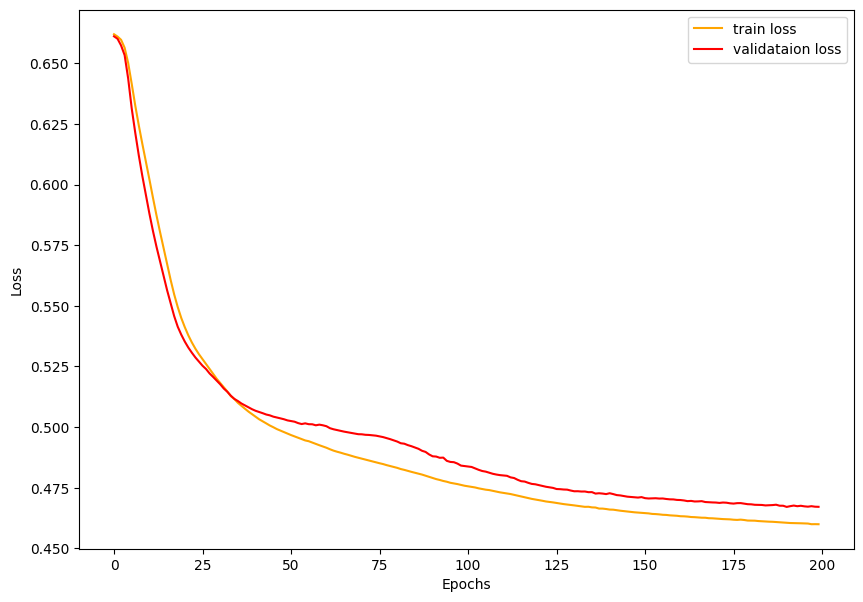

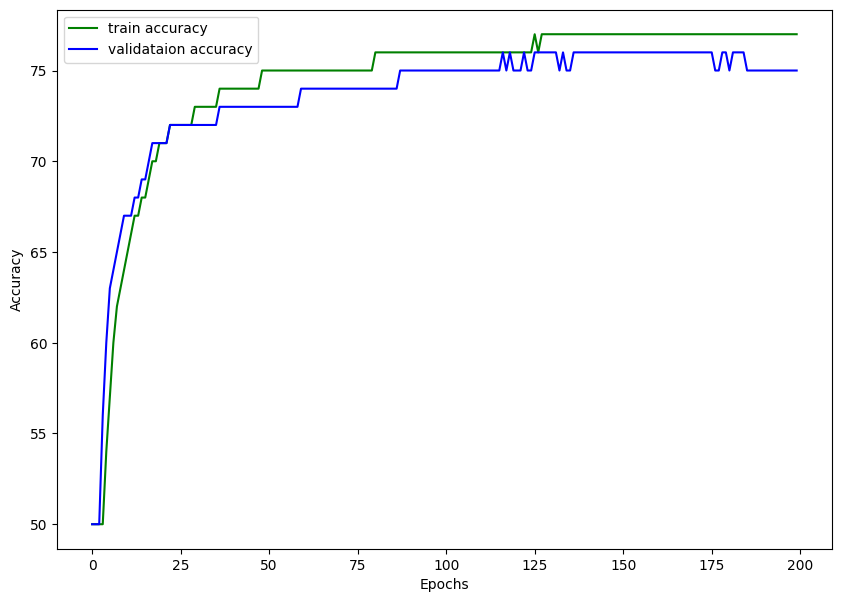

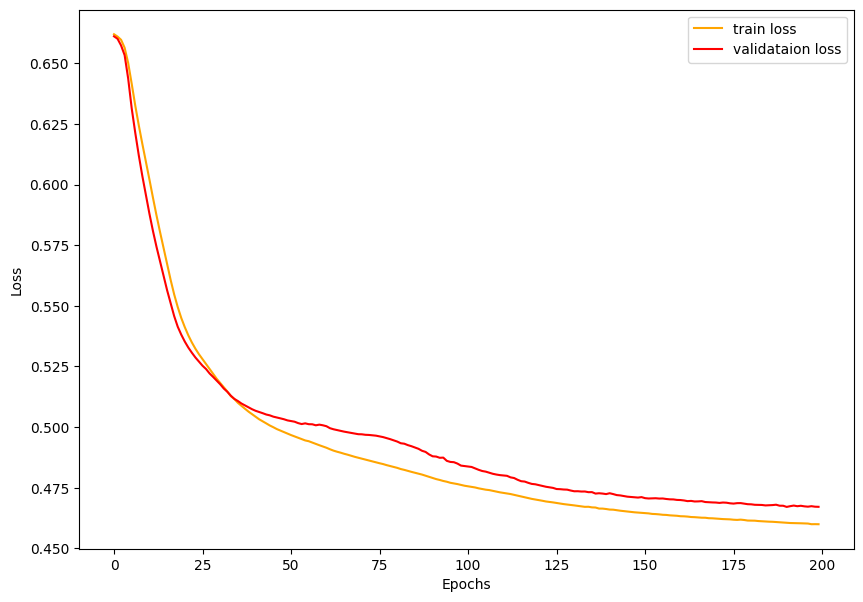

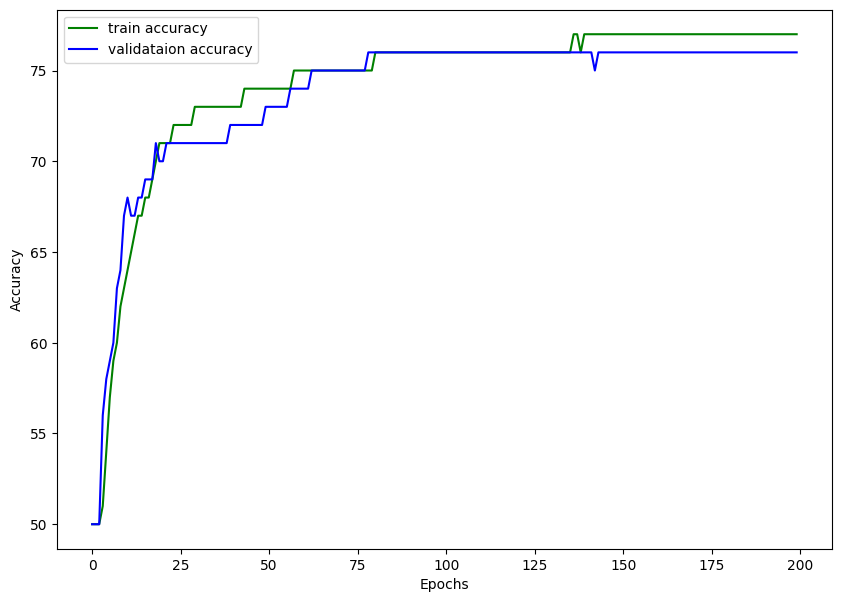

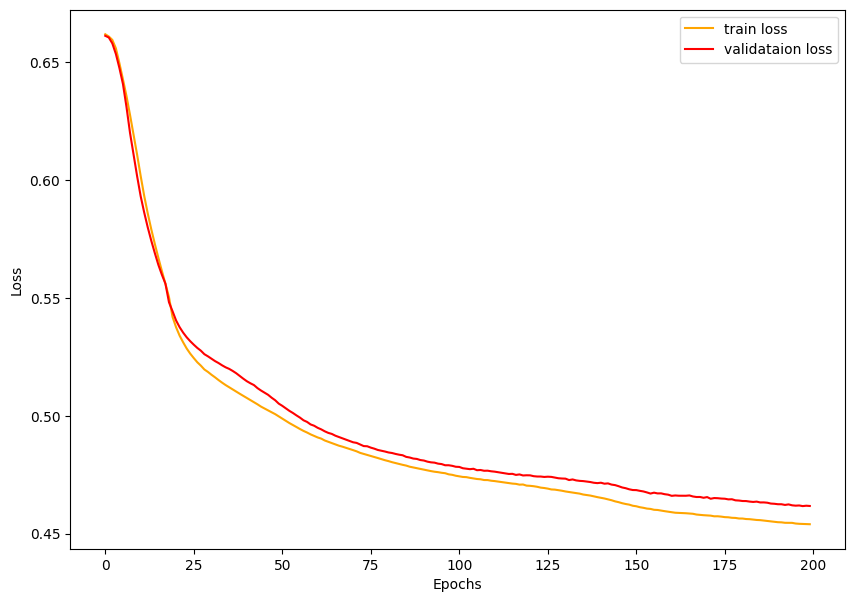

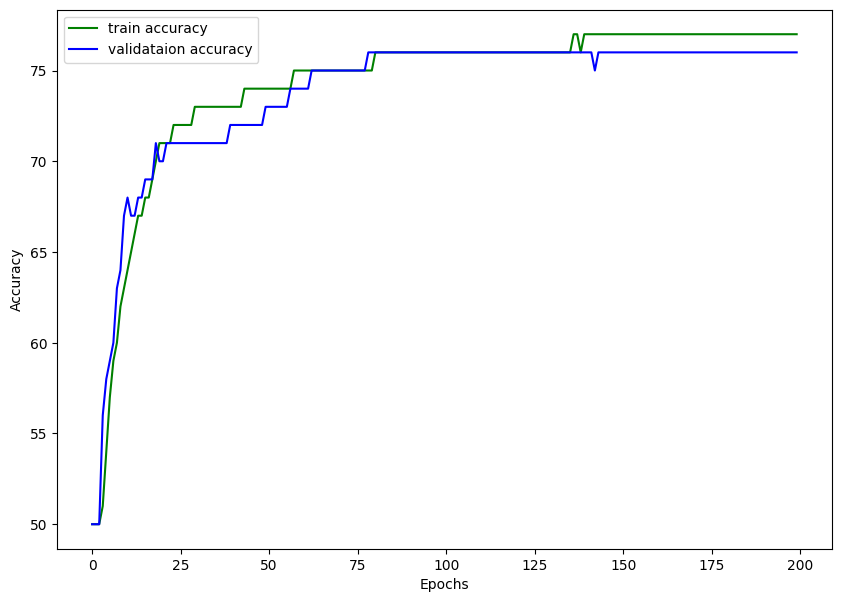

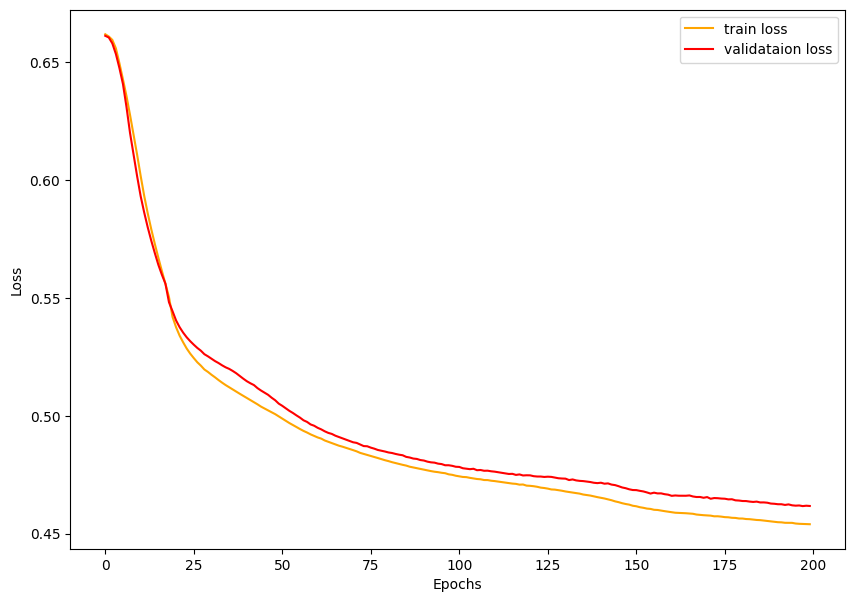

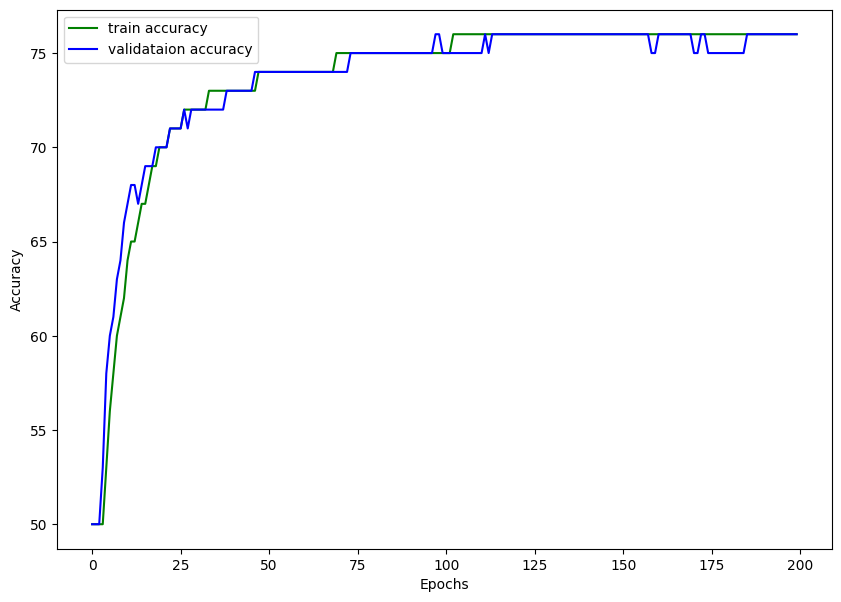

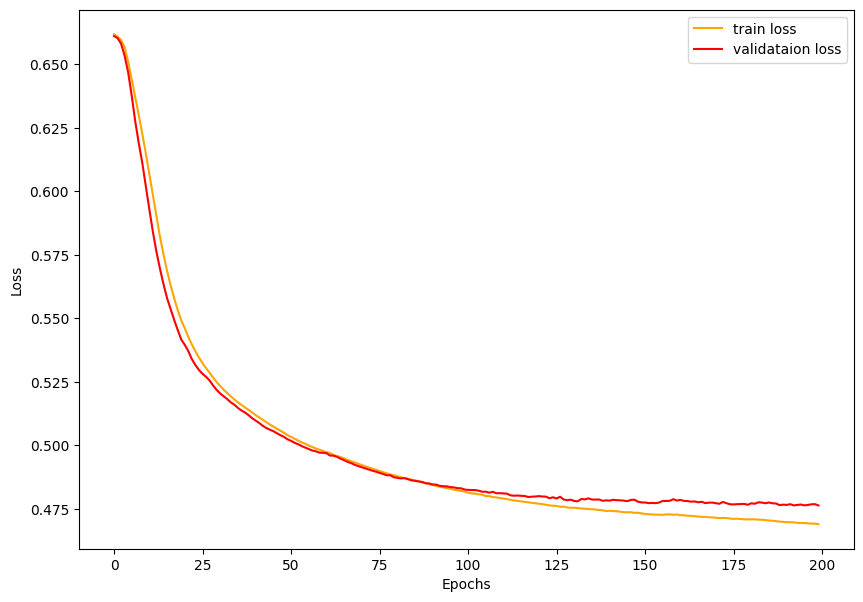

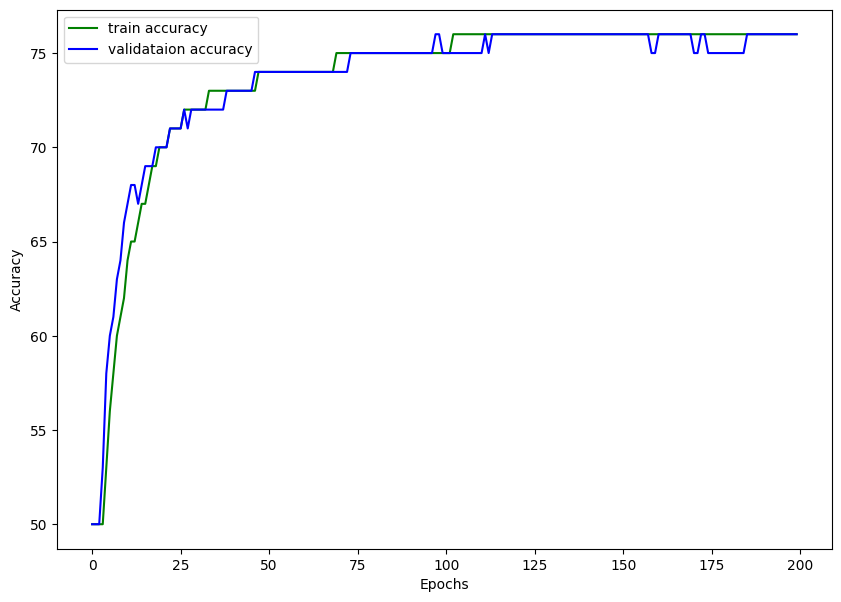

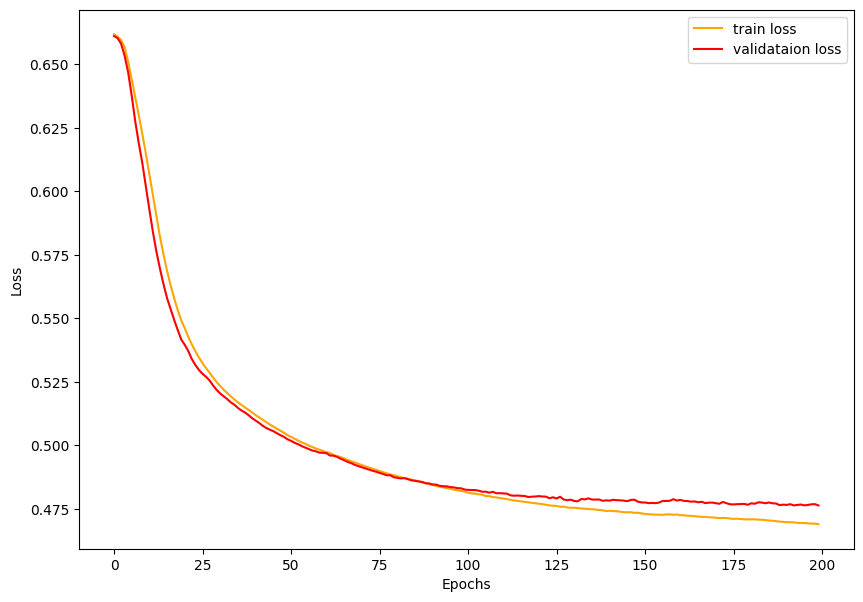

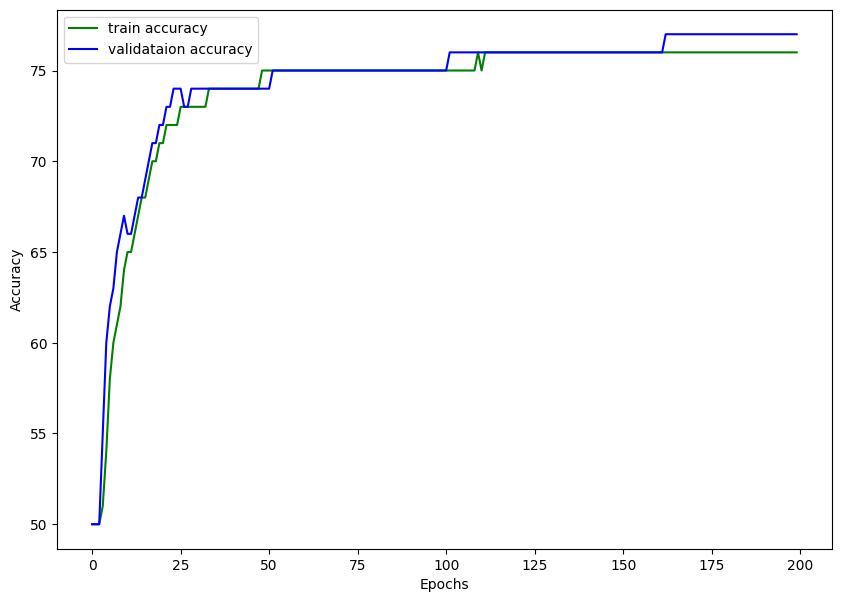

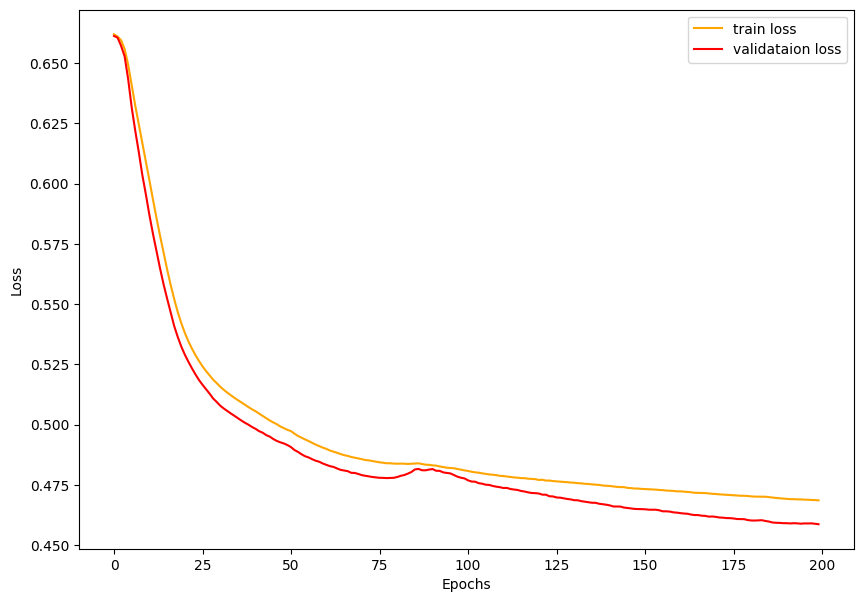

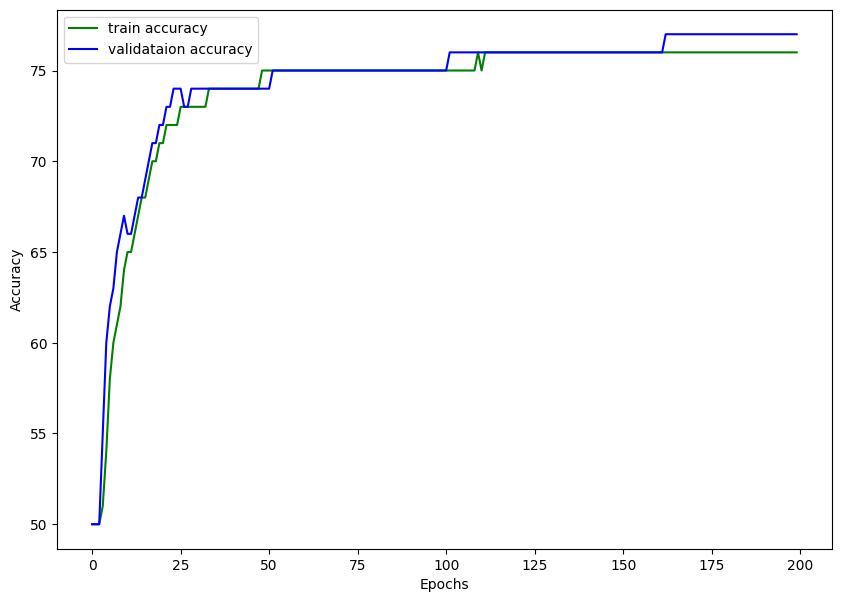

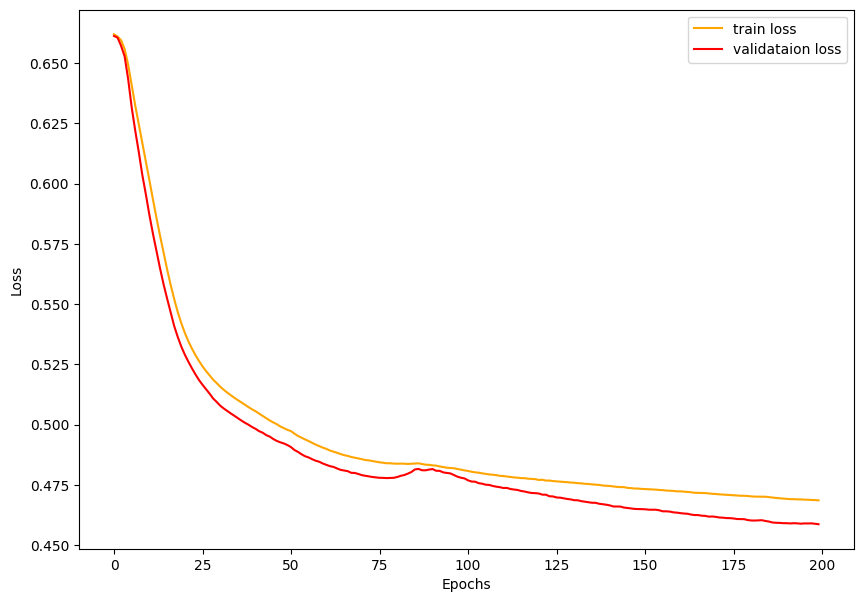

In [24]:
import shutil
from sklearn.model_selection import train_test_split


result_path = "training_results/"
if not os.path.isdir(result_path):
    os.mkdir(result_path)


if not os.path.isdir(save_model_folder_acc):
    os.mkdir(save_model_folder_acc)

if not os.path.isdir(save_model_folder_f1):
    os.mkdir(save_model_folder_f1)


def make_fold_folders(save_model_folder):
    for i in range(1, 6):
        save_pth = save_model_folder+f"fold_{i}"
        os.makedirs(save_pth, exist_ok=False)

make_fold_folders(save_model_folder_acc)
make_fold_folders(save_model_folder_f1)

config_1 = save_model_folder_acc+config_path.split('/')[-1]
config_2 = save_model_folder_f1+config_path.split('/')[-1]
config_list = [config_1, config_2]


for config_name in config_list:
    shutil.copy(config_path, config_name)
    

pos_num = len(y_t_pos_train)
for i in range(folds):
    print(f"Fold {i+1}:")
    save_fold_folder_acc = save_model_folder_acc+'fold_{0}/'.format(str(i+1))
    save_fold_folder_f1 = save_model_folder_f1+'fold_{0}/'.format(str(i+1))
    
    neg_fold_idx = [i*pos_num, i*pos_num+pos_num]
    neg_idx_start, neg_idx_end = neg_fold_idx[0], neg_fold_idx[1]
    sampled_indices = shuffle_indices[neg_idx_start:neg_idx_end]
    
    
    x_t_neg_samples = x_t_neg_train[sampled_indices]
    y_t_neg_samples = y_t_neg_train[sampled_indices]
    
    
    merge_x = np.concatenate([x_t_pos_train, x_t_neg_samples])
    merge_y = np.concatenate([y_t_pos_train, y_t_neg_samples])
    
    x_train, x_val, y_train, y_val = train_test_split(merge_x, merge_y, test_size=0.20, random_state=42)

    
    x_train = torch.FloatTensor(x_train)
    y_train = torch.FloatTensor(y_train)
    x_val = torch.FloatTensor(x_val)
    y_val = torch.FloatTensor(y_val)

    train_data = Dataset.SkeletonData(x_train, y_train)
    val_data = Dataset.SkeletonData(x_val, y_val)

    train_loader = DataLoader(dataset=train_data, batch_size=batch_size, shuffle=True,drop_last=True)
    val_loader = DataLoader(dataset=val_data, batch_size=batch_size, drop_last=True)
    Onedcnn.train_1dcnn_addfeature(train_loader, val_loader, save_fold_folder_acc, save_fold_folder_f1, loss_name, alpha)

    
        